# Regresión Lineal — Riesgo Operativo

**SI3015 - Fundamentos de Aprendizaje Automático**

En este cuaderno entrenaremos regresiones lineales con regularización L1 y L2 y con características polinómicas, usando validación cruzada para seleccionar buenos hiperparámetros. El objetivo es predecir el **riesgo operativo final** (`riesgo_final`) a partir de las variables del dataset de riesgo operativo.

In [1]:
import numpy as np
import pandas as pd

from scipy.stats import reciprocal

from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error

import matplotlib.pyplot as plt

In [2]:
# Definamos el "random_state" para que los resultados sean reproducibles:
random_state = 42
np.random.seed(random_state)

In [3]:
# Cambiemos la fuente de las gráficas de matplotlib:
plt.rc('font', family='serif', size=12)

In [4]:
# Carguemos el dataset de riesgo operativo (ya limpio):
df = pd.read_csv('dataset_riesgo_operativo_limpio.csv')
df.head()

,equipo,semana,t_prom,pct_fuera,pct_cumplimiento,interaccion,des_carga,correcciones,riesgo_final,riesgo_alto
0,1,1,4.370861,0.570429,0.839196,71.906094,0.078009,2,0.280227,0
1,1,2,4.003378,0.085720,0.790533,33.948811,0.360999,13,0.309325,0
2,1,3,2.911052,0.109095,0.510043,51.296957,0.262378,11,0.360259,1
3,1,4,4.598749,0.027999,0.984253,46.293994,0.045303,13,0.187575,0
4,1,5,2.797064,0.308541,0.755449,33.251529,0.303772,4,0.277347,0


In [5]:
# Definamos nuestros features (X) y variable objetivo (y):
# Usaremos t_prom como única variable para mantener la visualización 2D del notebook original.
# En la sección de árboles (Lecture 06) usaremos todos los features.
X = df[['t_prom']].values
y = df['riesgo_final'].values.reshape(-1, 1)

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (180, 1)
y shape: (180, 1)


In [6]:
# Separemos nuestros datos en conjuntos de entrenamiento y prueba:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

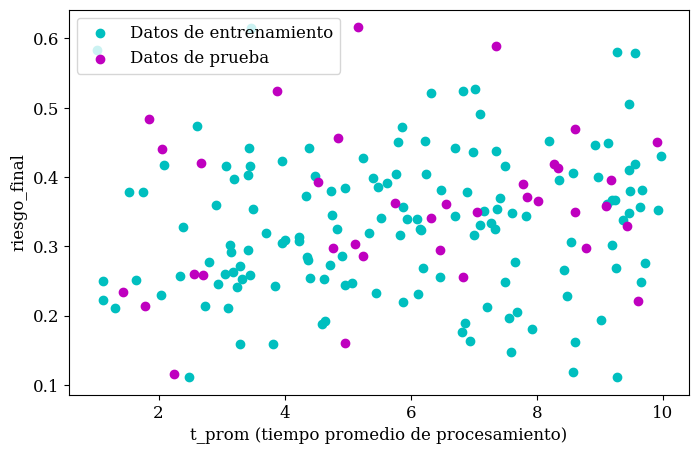

In [7]:
# Grafiquemos los datos de entrenamiento y prueba:
fig, ax = plt.subplots()
ax.scatter(X_train, y_train, c='c', label='Datos de entrenamiento')
ax.scatter(X_test, y_test, c='m', label='Datos de prueba')
ax.set_xlabel('t_prom (tiempo promedio de procesamiento)')
ax.set_ylabel('riesgo_final')
ax.legend()
fig.set_size_inches(1.6*5, 5)

In [8]:
# Definamos pipelines de scikit-learn con nuestros modelos base:

ridge_base = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('regressor', Ridge())
])

lasso_base = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('regressor', Lasso())
])

In [9]:
# Definamos las distribuciones de parámetros sobre las que haremos la búsqueda:
param_distributions = {
    'poly__degree': list(range(2, 10)),
    'regressor__alpha': reciprocal(1e-5, 1e3)
}

In [10]:
# Definamos nuestros modelos mediante RandomizedSearchCV:

ridge = RandomizedSearchCV(
    ridge_base,
    cv=4,
    param_distributions=param_distributions,
    n_iter=200,
    random_state=random_state
)

lasso = RandomizedSearchCV(
    lasso_base,
    cv=4,
    param_distributions=param_distributions,
    n_iter=200,
    random_state=random_state
)

In [11]:
# Entrenemos los modelos:
ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)

c:\Users\camil\OneDrive\Escritorio\CMMU\Camila_Martinez_Montoya_U\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.230e-01, tolerance: 1.107e-04
  model = cd_fast.enet_coordinate_descent(
c:\Users\camil\OneDrive\Escritorio\CMMU\Camila_Martinez_Montoya_U\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.784e-01, tolerance: 1.194e-04
  model = cd_fast.enet_coordinate_descent(
c:\Users\camil\OneDrive\Escritorio\CMMU\Camila_Martinez_Montoya_U\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to 

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...r', Lasso())])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'poly__degree': [2, 3, ...], 'regressor__alpha': <scipy.stats....0021D6A5217C0>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",200
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if N

In [12]:
# Obtengamos los mejores hiperparámetros encontrados para el modelo ridge:
ridge.best_params_

{'poly__degree': 8, 'regressor__alpha': np.float64(734.2552939552502)}

In [13]:
# Obtengamos los mejores hiperparámetros encontrados para el modelo LASSO:
lasso.best_params_

{'poly__degree': 8, 'regressor__alpha': np.float64(0.005155114649196501)}

In [14]:
# Obtengamos el R^2 y el MAE de prueba para el modelo ridge:
print('Modelo ridge')
print(f'R^2: {ridge.score(X_test, y_test)}')
print(f'MAE: {mean_absolute_error(y_test, ridge.predict(X_test))}')

Modelo ridge
R^2: -0.052220269283169696
MAE: 0.08607188562923992


In [15]:
# Obtengamos el R^2 y el MAE para el modelo LASSO:
print('Modelo LASSO')
print(f'R^2: {lasso.score(X_test, y_test)}')
print(f'MAE: {mean_absolute_error(y_test, lasso.predict(X_test))}')

Modelo LASSO
R^2: -0.055395981370500946
MAE: 0.08629003569037647


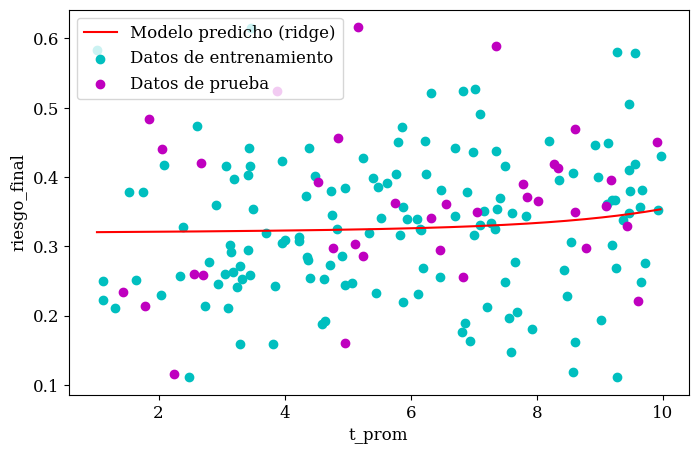

In [16]:
# Grafiquemos los datos junto con el modelo predicho por la regresión ridge:
X_plot = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)

fig, ax = plt.subplots()
ax.plot(X_plot, ridge.predict(X_plot), c='r', label='Modelo predicho (ridge)')
ax.scatter(X_train, y_train, c='c', label='Datos de entrenamiento')
ax.scatter(X_test, y_test, c='m', label='Datos de prueba')
ax.set_xlabel('t_prom')
ax.set_ylabel('riesgo_final')
ax.legend()
fig.set_size_inches(1.6*5, 5)

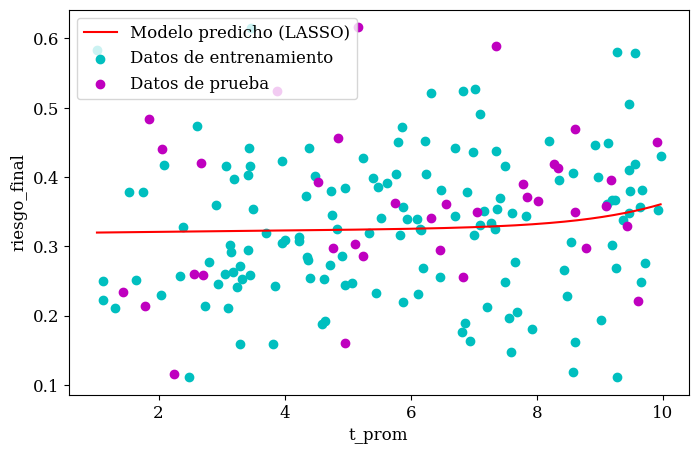

In [17]:
# Grafiquemos los datos junto con el modelo predicho por la regresión LASSO:
fig, ax = plt.subplots()
ax.plot(X_plot, lasso.predict(X_plot), c='r', label='Modelo predicho (LASSO)')
ax.scatter(X_train, y_train, c='c', label='Datos de entrenamiento')
ax.scatter(X_test, y_test, c='m', label='Datos de prueba')
ax.set_xlabel('t_prom')
ax.set_ylabel('riesgo_final')
ax.legend()
fig.set_size_inches(1.6*5, 5)

In [18]:
# Obtengamos los coeficientes y el intercepto de la regresión ridge:
print('Modelo ridge')
print(f"coeficientes: {ridge.best_estimator_['regressor'].coef_}")
print(f"intercepto: {ridge.best_estimator_['regressor'].intercept_}")

Modelo ridge
coeficientes: [0.00111287 0.00107569 0.00103229 0.00102605 0.00105619 0.00111112
 0.00117943 0.00125253]
intercepto: [0.32915632]


In [19]:
# Obtengamos los coeficientes y el intercepto de la regresión LASSO:
print('Modelo LASSO')
print(f"coeficientes: {lasso.best_estimator_['regressor'].coef_}")
print(f"intercepto: {lasso.best_estimator_['regressor'].intercept_}")

Modelo LASSO
coeficientes: [0.00239319 0.         0.         0.         0.         0.
 0.         0.00768724]
intercepto: [0.32915632]
